### Keyword finder pkl

In [2]:
import sys
from pathlib import Path

project_root = Path.cwd().parents[1]  # assuming you are in scraper/geocat/
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import scraper.configuration as config

db_name = config.WORKFLOW_GEOCAT_DATABASE_NAME
base_dir = config.WORKFLOW_GEOCAT_DATA


#### GeoCat Data

In [3]:
import sys, types, pickle
import pandas as pd
import os

# 🧩 Create a dummy Int64Index class for backward compatibility
class Int64Index(pd.Index):
    pass

# 🧩 Fake the old pandas module path and insert our dummy class
fake_mod = types.ModuleType("pandas.core.indexes.numeric")
fake_mod.Int64Index = Int64Index
sys.modules["pandas.core.indexes.numeric"] = fake_mod

# 🗂 Load the pickle file
with open(os.path.join(base_dir, db_name + ".pkl"), "rb") as f:
    geoheravester_data = pickle.load(f)

display(geoheravester_data)


{'dataset':                          dataset_identifier     origin  \
 0      000336c5-ce51-4518-a5f9-957da8c9c57e  geocat.ch   
 1      0005cc49-b66a-49b4-a30b-0aba36b28d01  geocat.ch   
 2      000fdf62-3b9f-4039-8090-af8a0b5eee6e  geocat.ch   
 3      001adc09-3aea-4641-9eb6-c06d9dc9f4af  geocat.ch   
 4      001d9c13-6501-4de5-b0f8-5e97afd8e258  geocat.ch   
 ...                                     ...        ...   
 17088                    VDG_TERRASSE_RESTO  geocat.ch   
 17089                         VDG_WC_PUBLIC  geocat.ch   
 17090                       VDG_WIFI_PUBLIC  geocat.ch   
 17091                       VIT_VIGNOBLE_AO  geocat.ch   
 17092                  VIT_VIGNOBLE_FEDERAL  geocat.ch   
 
                                    xml_filename dataset_language  \
 0      000336c5-ce51-4518-a5f9-957da8c9c57e.xml              NaN   
 1      0005cc49-b66a-49b4-a30b-0aba36b28d01.xml              NaN   
 2      000fdf62-3b9f-4039-8090-af8a0b5eee6e.xml              NaN   
 3 

In [4]:
import pandas as pd

# The pickle file likely contains a dictionary of DataFrames
# Check what keys exist:
print(geoheravester_data.keys())


dict_keys(['dataset', 'distribution', 'contact_point'])


In [5]:
for name, df in geoheravester_data.items():
    print(f"\n Table: {name}")
    print(f"Columns ({len(df.columns)}):")
    print(df.columns.tolist())



 Table: dataset
Columns (77):
['dataset_identifier', 'origin', 'xml_filename', 'dataset_language', 'dataset_title_de', 'dataset_title_de.1', 'dataset_keyword_de', 'dataset_keyword_de.1', 'dataset_description_de', 'dataset_description_de.1', 'dataset_title_unknown', 'dataset_keyword_unknown', 'dataset_description_unknown', 'dataset_title_en', 'dataset_title_en.1', 'dataset_keyword_en', 'dataset_keyword_en.1', 'dataset_description_en', 'dataset_description_en.1', 'dataset_keyword_fr', 'dataset_keyword_fr.1', 'dataset_title_fr', 'dataset_title_fr.1', 'dataset_description_fr', 'dataset_description_fr.1', 'dataset_title_it', 'dataset_title_it.1', 'dataset_keyword_it', 'dataset_keyword_it.1', 'dataset_description_it', 'dataset_description_it.1', 'dataset_title_rm', 'dataset_title_rm.1', 'dataset_keyword_rm', 'dataset_keyword_rm.1', 'dataset_description_rm', 'dataset_description_rm.1', 'dataset_publisher_name', 'dataset_publisher_url', 'dataset_spatial', 'dataset_theme', 'dataset_issued', 'd

In [ ]:
# Extract tables
m = geoheravester_data["dataset"]
d = geoheravester_data["distribution"]
c = geoheravester_data["contact_point"]

# Perform the joins exactly as in SQL
database_4M = (
    m.merge(c, on="dataset_identifier", how="left", suffixes=("", "_c"))
     .merge(d, on="dataset_identifier", how="left", suffixes=("", "_d"))
)

# Rename overlapping origin/xml_filename columns
database_4M = database_4M.rename(columns={
    "origin_c": "contact_origin",
    "xml_filename_c": "contact_xml_filename",
    "origin_d": "distribution_origin",
    "xml_filename_d": "distribution_xml_filename"
})

# Select only the relevant columns (no distribution_identifier — use distribution_id instead)
columns = list(m.columns) + [
    "contact_type", "contact_email", "contact_name",
    "contact_origin", "contact_xml_filename",
    "distribution_format", "distribution_access_url", "distribution_download_url",
    "distribution_format_name", "distribution_format_type",
    "distribution_license", "distribution_rights", "distribution_language",
    "distribution_id", "distribution_origin", "distribution_xml_filename",
    "distribution_description_de", "distribution_description_fr",
    "distribution_description_it", "distribution_description_en",
    "distribution_description_rm"
]

# Filter only existing columns (to avoid KeyError if any name is missing)
existing_columns = [col for col in columns if col in database_4M.columns]
database_4M = database_4M[existing_columns]

print(f"Gesamtzeilen nach Join: {len(database_4M)}")
display(database_4M)


Scanning URLs:  25%|██▍       | 247/1000 [00:27<00:47, 15.71it/s]

#### GeoHarvester Data

In [7]:
import sys, types, pickle
import pandas as pd

# 🧩 Create a dummy Int64Index class for backward compatibility
class Int64Index(pd.Index):
    pass

# 🧩 Fake the old pandas module path and insert our dummy class
fake_mod = types.ModuleType("pandas.core.indexes.numeric")
fake_mod.Int64Index = Int64Index
sys.modules["pandas.core.indexes.numeric"] = fake_mod

# 🗂 Load the pickle file
with open("../data/_merged_data.pkl", "rb") as f:
    geoheravester_data = pickle.load(f)

display(geoheravester_data)


C:\Users\ma1169948\AppData\Local\Temp\ipykernel_28380\444860366.py:15: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  geoheravester_data = pickle.load(f)


,provider,title,name,preview,tree,group,abstract,keywords,legend,contact,...,abstract_it,abstract_fr,keywords_en,keywords_de,keywords_it,keywords_fr,keywords_nlp_en,keywords_nlp_de,keywords_nlp_it,keywords_nlp_fr
0,KT_AI,Abwasser Werkplan Gde,ch.geoportal.ver_entsorgung_kommunikation.205....,https://map.geo.admin.ch/?bgLayer=ch.swisstopo...,KT_AI/WMS Geoportal.ch/ch.geoportal.ktai,ch.geoportal.ktai,Diese Karte zeigt die Werkleitungen der Abwass...,,https://www.geoportal.ch/services/wms/ktai?req...,,...,Questa mappa mostra le condotte di smaltimento...,Cette carte montre les canalisations d évacuat...,,,,,"sewer network shown,inlet shafts,factory lines...","kanalisationsnetz dargestellt, einlaufschächte...","rete fognaria mostrata,alberi di aspirazione,l...","réseau d égouts illustré,arbres d admission,li..."
1,KT_AI,Amphibienvorkommen Kt,ch.geoportal.wald_flora_fauna.53.0.amphibienvo...,https://map.geo.admin.ch/?bgLayer=ch.swisstopo...,KT_AI/WMS Geoportal.ch/ch.geoportal.ktai,ch.geoportal.ktai,Diese Karte zeigt die Amphibienvorkommen in de...,,https://www.geoportal.ch/services/wms/ktai?req...,,...,Questa carta mostra la presenza di anfibi nei ...,Cette carte montre la présence d amphibiens da...,,,,,"amphibienvorkommen, karte zeigt, ar, kantonen ...","amphibienvorkommen,karte zeigt,ar,kantonen sg,ai","presenza di anfibi,mostra la mappa,ar,cantoni,ai","présence d amphibiens,la carte montre,ar,canto..."
2,KT_AI,Amtliche Vermessung farbig Gde,ch.geoportal.basiskarten_bodenbedeckung_bildda...,https://map.geo.admin.ch/?bgLayer=ch.swisstopo...,KT_AI/WMS Geoportal.ch/ch.geoportal.ktai,ch.geoportal.ktai,Diese Karte zeigt in roter Farbe den pendenten...,AV,https://www.geoportal.ch/services/wms/ktai?req...,,...,Questa carta mostra in rosso lo stato attuale ...,Cette carte montre en rouge l état actuel ou p...,OF,AV,DI,DE,"official survey,projected status,map shows,red...","amtlichen vermessung, projektierten stand, kar...","sondaggio ufficiale,stato previsto,mostra la m...","enquête officielle,statut projeté,la carte mon..."
3,KT_AI,Amtliche Vermessung Gde,ch.geoportal.basiskarten_bodenbedeckung_bildda...,https://map.geo.admin.ch/?bgLayer=ch.swisstopo...,KT_AI/WMS Geoportal.ch/ch.geoportal.ktai,ch.geoportal.ktai,Diese Karte zeigt in roter Farbe den pendenten...,AV,https://www.geoportal.ch/services/wms/ktai?req...,,...,Questa carta mostra in rosso lo stato attuale ...,Cette carte montre en rouge l état actuel ou p...,OF,AV,DI,DE,"official survey,projected status,grayscale fil...","amtlichen vermessung, projektierten stand, gra...","sondaggio ufficiale,stato previsto,riempimento...","enquête officielle,statut projeté,remplissage ..."
4,KT_AI,Amtliche Vermessung Gde Kt AR,ch.geoportal.basiskarten_bodenbedeckung_bildda...,https://map.geo.admin.ch/?bgLayer=ch.swisstopo...,KT_AI/WMS Geoportal.ch/ch.geoportal.ktai,ch.geoportal.ktai,Diese Karte zeigt in roter Farbe den pendenten...,AV,https://www.geoportal.ch/services/wms/ktai?req...,,...,Questa carta mostra in rosso lo stato attuale ...,Cette carte montre en rouge l état actuel ou p...,OF,AV,DI,DE,"official survey,projected status,grayscale fil...","amtlichen vermessung, projektierten stand, gra...","sondaggio ufficiale,stato previsto,riempimento...","enquête officielle,statut projeté,remplissage ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2567,ASIT,Fond ASIT - cadastral,asitvd.fond_cadastral,https://map.geo.admin.ch/?bgLayer=ch.swisstopo...,Service de fond de plan WMTS ASIT: données Eta...,,,,https://wmts.asit-asso.ch/wmts/1.0.0/WMTSCapa...,n.a.,...,,,,,,,,,,
2568,SOSM,SOSM standard,SOSM standard,https://map.geo.admin.ch/?bgLayer=ch.swisstopo...,,,,,https://tile.osm.ch/1.0.0/WMTSCapabilities.xml,n.a.,...,,,,,,,,,,
2569,SOSM,SOSM swiss style,SOSM swiss style,https://map.geo.admin.ch/?bgLayer=ch.swisstopo...,,,,,https://tile.osm.ch/1.0.0/WMTSCapabilities.xml,n.a.,...,,,,,,,,,,
2570,SOSM,SOSM CH1903,SOSM CH1903,https://map.geo.admin.ch/?bgLayer=ch

#### Search Data

### geocat: remove not usable features

In [8]:
# import pandas as pd
# import numpy as np

# access_url_columns_4M = [
#     'dataset_description_de','dataset_description_fr','dataset_description_it',
#     'dataset_description_en','dataset_description_rm',
#     'distribution_description_de','distribution_description_fr',
#     'distribution_description_it','distribution_description_en',
#     'distribution_description_rm'
# ]

# # Logging function
# def log_step(step_name, before_count, df_after):
#     after_count = len(df_after)
#     dropped = before_count - after_count
#     print(f"{step_name}: before = {before_count}, after = {after_count}, dropped = {dropped}")
#     return after_count


# # ------- Step 0 -------
# count_start = len(database_4M)
# print(f"Start: {count_start} rows")


# # ------- Step 1: remove rows where all text columns are empty -------
# before = len(database_4M)
# mask_nonempty = (database_4M[access_url_columns_4M] != '').any(axis=1)
# database_step1 = database_4M[mask_nonempty]
# after = log_step("Step 1 - remove empty text rows", before, database_step1)


# # ------- Step 2: drop duplicates -------
# before = after
# database_step2 = database_step1.drop_duplicates(subset=access_url_columns_4M, keep='first')
# after = log_step("Step 2 - drop duplicates", before, database_step2)


# # ------- Step 3: keep only rows where at least one text column value is unique -------
# before = after

# value_counts = {col: database_step2[col].value_counts() for col in access_url_columns_4M}

# def row_has_unique_text(row):
#     for col in access_url_columns_4M:
#         val = row[col]
#         if pd.notna(val) and value_counts[col].get(val, 0) == 1:
#             return True
#     return False

# mask_unique = database_step2.apply(row_has_unique_text, axis=1)
# database_step3 = database_step2[mask_unique]
# after = log_step("Step 3 - keep rows with unique text", before, database_step3)


# print(f"Final row count: {after}")


# # ------- Finalize -------
# database_4M = database_step3.copy()
# database_4M.loc[:, 'matched_description'] = False
# database_4M.loc[:, 'match_score'] = None


prepare text abstarct geoharvester data

In [17]:
import pandas as pd

TERM = "wms_ows_keywordlist"

# ensure strings
keywords = geoheravester_data["keywords"].astype(str)

# find all rows containing the term
mask = keywords.str.contains(TERM, case=False, na=False)

# extract matching rows
result_df = geoheravester_data[mask].copy()

# count
count_matches = mask.sum()

print("Matches:", count_matches)


Matches: 793


In [ ]:
import pandas as pd
from tqdm import tqdm

DEV_LIMIT = 1000       # set to None for full run

urls = database_4M["distribution_access_url"].astype(str)
names = geoheravester_data["name"].astype(str)

# apply dev-mode limit
if DEV_LIMIT is not None:
    urls = urls.iloc[:DEV_LIMIT]

matches = []

for url_index, url in tqdm(urls.items(), total=len(urls), desc="Scanning URLs"):
    for name_index, name in names.items():

        if name.strip() and name in url:

            matches.append({
                # base match info
                "url_index": url_index,
                "name_index": name_index,
                "distribution_access_url": url,
                "name": name,

                # extra fields from geoharvester
                "geo_keywords": geoheravester_data.at[name_index, "keywords"],
                "geo_abstract": geoheravester_data.at[name_index, "abstract"],

                # extra fields from 4M
                "dataset_title_de": database_4M.at[url_index, "dataset_title_de"],
                "dataset_keyword_de": database_4M.at[url_index, "dataset_keyword_de"],
                "dataset_description_de": database_4M.at[url_index, "dataset_description_de"]
            })

result_df = pd.DataFrame(matches)


Scanning URLs: 100%|██████████| 60697/60697 [00:08<00:00, 6784.64it/s]


In [19]:
display(result_df)

,url_index,name_index,distribution_access_url,name
0,35,56572,https://map.geo.admin.ch/?layers=ch.bakom.notr...,ch.bakom.notruf
1,35,56594,https://map.geo.admin.ch/?layers=ch.bakom.notr...,ch.bakom.notruf-147_zentral
2,39,56572,https://data.geo.admin.ch/browser/index.html#/...,ch.bakom.notruf
3,41,56572,https://api3.geo.admin.ch/rest/services/api/Ma...,ch.bakom.notruf
4,41,56594,https://api3.geo.admin.ch/rest/services/api/Ma...,ch.bakom.notruf-147_zentral
...,...,...,...,...
3493,50097,56354,https://map.geo.admin.ch/?layers=ch.swisstopo....,ch.swisstopo.swisstlm3d-uebrigerverkehr
3494,50102,56352,https://map.geo.admin.ch/?topic=swisstopo&lang...,ch.swisstopo.swisstlm3d-karte-farbe
3495,50103,56354,https://api3.geo.admin.ch/rest/services/api/Ma...,ch.swisstopo.swisstlm3d-uebrigerverkehr
3496,50126,56731,https://map.geo.admin.ch/?layers=ch.bafu.neoph...,ch.bafu.neophyten-haargurke


In [9]:
from rapidfuzz import process, fuzz, utils
import numpy as np
import pandas as pd
from tqdm import tqdm

SIMILARITY_THRESHOLD = 80
CHUNK_SIZE = 20000     # adjust depending on RAM

# --------------------------------------------------
# A: Filter empty names from geoharvester
# --------------------------------------------------

mask_nonempty = geoheravester_data["name"].astype(str).str.strip() != ""
geo_valid = geoheravester_data[mask_nonempty].copy()

geo_valid["name_norm"] = geo_valid["name"].apply(utils.default_process)
geo_valid["name_len"] = geo_valid["name_norm"].str.len()

geo_names = geo_valid["name_norm"].tolist()
geo_lengths = geo_valid["name_len"].to_numpy()

# --------------------------------------------------
# B: Flatten distribution_access_url
# --------------------------------------------------

db_long = (
    database_4M[["distribution_access_url"]]
    .reset_index()
    .melt(id_vars="index", value_name="text")
    .drop(columns="variable")
    .dropna(subset=["text"])
)

db_long["text_norm"] = db_long["text"].apply(utils.default_process)
db_long["text_len"] = db_long["text_norm"].str.len()

db_texts = db_long["text_norm"].tolist()
db_lengths = db_long["text_len"].to_numpy()

# Prepare result columns
db_long["similarity_score"] = np.nan
db_long["best_geo_index"] = np.nan
db_long["title"] = None
db_long["abstract"] = None
db_long["name"] = None

# --------------------------------------------------
# C: Chunked cdist with tqdm
# --------------------------------------------------

n = len(db_texts)
best_scores = np.full(n, -1.0)
best_indices = np.full(n, -1, dtype=int)

for start in tqdm(range(0, n, CHUNK_SIZE), desc="Matching"):
    end = min(start + CHUNK_SIZE, n)

    chunk_texts = db_texts[start:end]
    chunk_lengths = db_lengths[start:end]

    # compute similarity for this chunk
    scores = process.cdist(
        chunk_texts,
        geo_names,
        scorer=fuzz.ratio,
        workers=-1
    )

    # length mask
    len_mask = np.abs(chunk_lengths[:, None] - geo_lengths[None, :]) <= 20
    scores[~len_mask] = -1

    # best match inside chunk
    chunk_best_idx = scores.argmax(axis=1)
    chunk_best_scores = scores.max(axis=1)

    best_scores[start:end] = chunk_best_scores
    best_indices[start:end] = chunk_best_idx

# --------------------------------------------------
# D: Apply threshold and assign metadata
# --------------------------------------------------

mask_valid = best_scores >= SIMILARITY_THRESHOLD

db_long.loc[mask_valid, "similarity_score"] = best_scores[mask_valid]
db_long.loc[mask_valid, "best_geo_index"] = best_indices[mask_valid]

db_long.loc[mask_valid, "name"] = geo_valid["name"].iloc[best_indices[mask_valid]].values
db_long.loc[mask_valid, "abstract"] = geo_valid["abstract"].iloc[best_indices[mask_valid]].values
db_long.loc[mask_valid, "title"] = geo_valid["title"].iloc[best_indices[mask_valid]].values

# --------------------------------------------------
# E: Merge back into database_4M
# --------------------------------------------------

database_4M = database_4M.copy()

database_4M["similarity_score"] = np.nan
database_4M["best_geo_index"] = np.nan
database_4M["abstract"] = None
database_4M["title"] = None
database_4M["name"] = None

database_4M.loc[db_long["index"], "similarity_score"] = db_long["similarity_score"].values
database_4M.loc[db_long["index"], "best_geo_index"] = db_long["best_geo_index"].values
database_4M.loc[db_long["index"], "abstract"] = db_long["abstract"].values
database_4M.loc[db_long["index"], "title"] = db_long["title"].values
database_4M.loc[db_long["index"], "name"] = db_long["name"].values


Matching:   0%|          | 0/3 [00:00<?, ?it/s]

: 

: 

In [127]:
filtered = database_4M[database_4M["similarity_score"] >= SIMILARITY_THRESHOLD]

# display(filtered)

result = filtered[
    [
        "similarity_score",
        "abstract",
        "title",
        "dataset_title_de",
        "dataset_description_de",
        "dataset_keyword_de",
        "dataset_description_fr",
        "dataset_description_it",
        "dataset_description_en",
        "dataset_description_rm",
        "distribution_description_de",
        "distribution_description_fr",
        "distribution_description_it",
        "distribution_description_en",
        "distribution_description_rm"
    ]
]

display(result)


,similarity_score,abstract,title,dataset_title_de,dataset_description_de,dataset_keyword_de,dataset_description_fr,dataset_description_it,dataset_description_en,dataset_description_rm,distribution_description_de,distribution_description_fr,distribution_description_it,distribution_description_en,distribution_description_rm
209,100.000000,"ÖREB: Nutzungsplanung kommunal, Steinerberg, ü...","ÖREB: Nutzungsplanung kommunal, Steinerberg, ü...",Nutzungsplanung kommunal Gemeinde Steinerberg,Nutzungsplanung kommunal. Geobasisdatensätze N...,NaN,NaN,NaN,NaN,NaN,"ÖREB: Nutzungsplanung kommunal, Steinerberg, ü...",NaN,NaN,NaN,NaN
210,100.000000,"ÖREB: Nutzungsplanung kommunal, Steinerberg, o...","ÖREB: Nutzungsplanung kommunal, Steinerberg, o...",Nutzungsplanung kommunal Gemeinde Steinerberg,Nutzungsplanung kommunal. Geobasisdatensätze N...,NaN,NaN,NaN,NaN,NaN,"ÖREB: Nutzungsplanung kommunal, Steinerberg, o...",NaN,NaN,NaN,NaN
211,100.000000,"ÖREB: Nutzungsplanung kommunal, Steinerberg, l...","ÖREB: Nutzungsplanung kommunal, Steinerberg, l...",Nutzungsplanung kommunal Gemeinde Steinerberg,Nutzungsplanung kommunal. Geobasisdatensätze N...,NaN,NaN,NaN,NaN,NaN,"ÖREB: Nutzungsplanung kommunal, Steinerberg, l...",NaN,NaN,NaN,NaN
212,84.800000,"ÖREB: Nutzungsplanung kommunal, Steinerberg, ü...","ÖREB: Nutzungsplanung kommunal, Steinerberg, ü...",Nutzungsplanung kommunal Gemeinde Steinerberg,Nutzungsplanung kommunal. Geobasisdatensätze N...,NaN,NaN,NaN,NaN,NaN,"ÖREB: Nutzungsplanung kommunal, Steinerberg, G...",NaN,NaN,NaN,NaN
297,100.000000,Naturgefahrenkarte: Perimeter wo die die Natur...,Perimeter nicht beurteilt,Naturgefahrenkarte,Integrale Naturgefahrenkarten setzen sich aus ...,NaN,NaN,NaN,NaN,NaN,Naturgefahrenkarte: Perimeter wo die die Natur...,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55124,91.875000,Die Karte -Strassenlärm Kt AR- zeigt die Kanto...,Strassenlärm Kt AR,Kanton St.Gallen - Strassenlärmbelastungskataster,Dieser Datensatz zeigt die Kantonsstrassen mit...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
55125,100.000000,Die Karte Wasserkraftpotential zeigt die Klein...,Wasserkraftpotential Kt AR,Kanton Appenzell Ausserrhoden - Wasserkraftpot...,Die Karte Wasserkraftpotential zeigt die Klein...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
55128,100.000000,Die Waldbestandeskarte dient der forstlichen P...,Bestandeskarte 2019 Kt AR/AI,Kanton St.Gallen - Wald Bestandeskarte 2009 Kt SG,Die Waldbestandeskarte dient der forstlichen P...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
55129,88.188976,Das Orthofoto zeigt die Landschaft in einer Lu...,Orthofoto,Berg SG - Orthofoto Berg SG,Das Orthofoto zeigt die Landschaft in einer Lu...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


=== Keyword Presence Analysis ===
Gesamt: 42
Nur source_keywords: 0 (0.0%)
Nur dataset_keywords: 24 (57.1%)
Beide vorhanden: 18 (42.9%)
→ Davon mit 'wms_ows_keywordlist': 6 (14.3%)


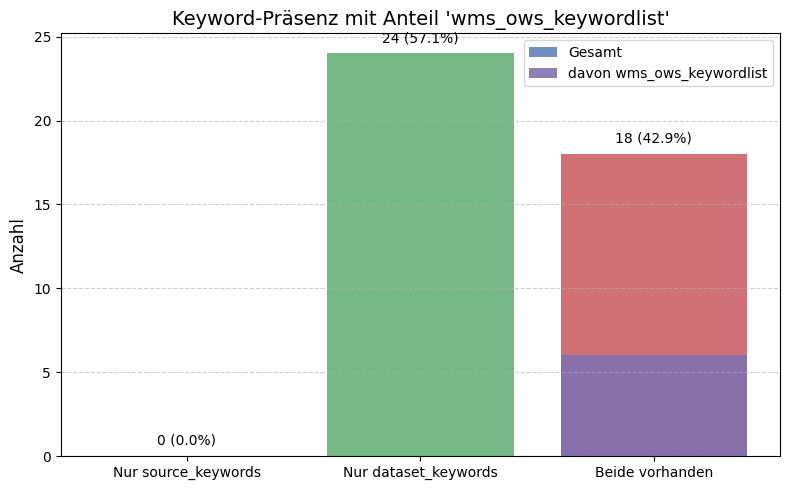


=== DataFrames ===
Nur source_keywords:


,match_score,source_abstract,dataset_description_de,dataset_description_fr,dataset_description_it,dataset_description_en,dataset_description_rm,source_keywords,dataset_keyword_de,dataset_keyword_fr,dataset_keyword_it,dataset_keyword_en,dataset_keyword_rm,has_dataset_keywords,has_source_keywords


Nur dataset_keywords:


,match_score,source_abstract,dataset_description_de,dataset_description_fr,dataset_description_it,dataset_description_en,dataset_description_rm,source_keywords,dataset_keyword_de,dataset_keyword_fr,dataset_keyword_it,dataset_keyword_en,dataset_keyword_rm,has_dataset_keywords,has_source_keywords
18255,98.499062,Das BAFU verwaltet die Daten zu Hochwassererei...,Das BAFU verwaltet die Daten zu Hochwassererei...,"L’OFEV gère les données relatives aux crues, l...","L’UFAM gestisce i dati relativi alle piene, li...",Data on flood events is managed and statistica...,Il UFAM administrescha las datas davart evenim...,,"['GEWISS', 'opendata.swiss', 'Gewässer', 'BGDI...","['GEWISS', 'opendata.swiss', 'eaux (géographie...","['GEWISS', 'opendata.swiss', 'acque (geografia...","['GEWISS', 'opendata.swiss', 'water (geographi...",['opendata.swiss'],True,False
18256,98.499062,Das BAFU verwaltet die Daten zu Hochwassererei...,Das BAFU verwaltet die Daten zu Hochwassererei...,"L’OFEV gère les données relatives aux crues, l...","L’UFAM gestisce i dati relativi alle piene, li...",Data on flood events is managed and statistica...,Il UFAM administrescha las datas davart evenim...,,"['GEWISS', 'opendata.swiss', 'Gewässer', 'BGDI...","['GEWISS', 'opendata.swiss', 'eaux (géographie...","['GEWISS', 'opendata.swiss', 'acque (geografia...","['GEWISS', 'opendata.swiss', 'water (geographi...",['opendata.swiss'],True,False
18257,98.499062,Das BAFU verwaltet die Daten zu Hochwassererei...,Das BAFU verwaltet die Daten zu Hochwassererei...,"L’OFEV gère les données relatives aux crues, l...","L’UFAM gestisce i dati relativi alle piene, li...",Data on flood events is managed and statistica...,Il UFAM administrescha las datas davart evenim...,,"['GEWISS', 'opendata.swiss', 'Gewässer', 'BGDI...","['GEWISS', 'opendata.swiss', 'eaux (géographie...","['GEWISS', 'opendata.swiss', 'acque (geografia...","['GEWISS', 'opendata.swiss', 'water (geographi...",['opendata.swiss'],True,False


Beide vorhanden:


,match_score,source_abstract,dataset_description_de,dataset_description_fr,dataset_description_it,dataset_description_en,dataset_description_rm,source_keywords,dataset_keyword_de,dataset_keyword_fr,dataset_keyword_it,dataset_keyword_en,dataset_keyword_rm,has_dataset_keywords,has_source_keywords
11997,99.357945,"Die Sammlung von Geodaten -Standplätze, Durchg...","Die Sammlung von Geodaten ""Standplätze, Durchg...","La collection de géodonnées ""Aires de stationn...","La raccolta di geodati “Aree di sosta, passagg...","The collection of geodata ""Sites, transit site...",La collecziun da geodatas «Plazzas da staziuna...,ch.bak.halteplaetze-jenische_sinti_roma.wms_ow...,"['BGDI Bundesgeodaten-Infrastruktur', 'Bund', ...",['IFDG l’Infrastructure Fédérale de données gé...,['IFDG Infrastruttura federale dei dati geogra...,"['FSDI Federal Spatial Data Infrastructure', '...",['opendata.swiss'],True,True
11998,99.357945,"Die Sammlung von Geodaten -Standplätze, Durchg...","Die Sammlung von Geodaten ""Standplätze, Durchg...","La collection de géodonnées ""Aires de stationn...","La raccolta di geodati “Aree di sosta, passagg...","The collection of geodata ""Sites, transit site...",La collecziun da geodatas «Plazzas da staziuna...,ch.bak.halteplaetze-jenische_sinti_roma.wms_ow...,"['BGDI Bundesgeodaten-Infrastruktur', 'Bund', ...",['IFDG l’Infrastructure Fédérale de données gé...,['IFDG Infrastruttura federale dei dati geogra...,"['FSDI Federal Spatial Data Infrastructure', '...",['opendata.swiss'],True,True
11999,99.357945,"Die Sammlung von Geodaten -Standplätze, Durchg...","Die Sammlung von Geodaten ""Standplätze, Durchg...","La collection de géodonnées ""Aires de stationn...","La raccolta di geodati “Aree di sosta, passagg...","The collection of geodata ""Sites, transit site...",La collecziun da geodatas «Plazzas da staziuna...,ch.bak.halteplaetze-jenische_sinti_roma.wms_ow...,"['BGDI Bundesgeodaten-Infrastruktur', 'Bund', ...",['IFDG l’Infrastructure Fédérale de données gé...,['IFDG Infrastruttura federale dei dati geogra...,"['FSDI Federal Spatial Data Infrastructure', '...",['opendata.swiss'],True,True


Beide vorhanden + 'wms_ows_keywordlist':


,match_score,source_abstract,dataset_description_de,dataset_description_fr,dataset_description_it,dataset_description_en,dataset_description_rm,source_keywords,dataset_keyword_de,dataset_keyword_fr,dataset_keyword_it,dataset_keyword_en,dataset_keyword_rm,has_dataset_keywords,has_source_keywords
11997,99.357945,"Die Sammlung von Geodaten -Standplätze, Durchg...","Die Sammlung von Geodaten ""Standplätze, Durchg...","La collection de géodonnées ""Aires de stationn...","La raccolta di geodati “Aree di sosta, passagg...","The collection of geodata ""Sites, transit site...",La collecziun da geodatas «Plazzas da staziuna...,ch.bak.halteplaetze-jenische_sinti_roma.wms_ow...,"['BGDI Bundesgeodaten-Infrastruktur', 'Bund', ...",['IFDG l’Infrastructure Fédérale de données gé...,['IFDG Infrastruttura federale dei dati geogra...,"['FSDI Federal Spatial Data Infrastructure', '...",['opendata.swiss'],True,True
11998,99.357945,"Die Sammlung von Geodaten -Standplätze, Durchg...","Die Sammlung von Geodaten ""Standplätze, Durchg...","La collection de géodonnées ""Aires de stationn...","La raccolta di geodati “Aree di sosta, passagg...","The collection of geodata ""Sites, transit site...",La collecziun da geodatas «Plazzas da staziuna...,ch.bak.halteplaetze-jenische_sinti_roma.wms_ow...,"['BGDI Bundesgeodaten-Infrastruktur', 'Bund', ...",['IFDG l’Infrastructure Fédérale de données gé...,['IFDG Infrastruttura federale dei dati geogra...,"['FSDI Federal Spatial Data Infrastructure', '...",['opendata.swiss'],True,True
11999,99.357945,"Die Sammlung von Geodaten -Standplätze, Durchg...","Die Sammlung von Geodaten ""Standplätze, Durchg...","La collection de géodonnées ""Aires de stationn...","La raccolta di geodati “Aree di sosta, passagg...","The collection of geodata ""Sites, transit site...",La collecziun da geodatas «Plazzas da staziuna...,ch.bak.halteplaetze-jenische_sinti_roma.wms_ow...,"['BGDI Bundesgeodaten-Infrastruktur', 'Bund', ...",['IFDG l’Infrastructure Fédérale de données gé...,['IFDG Infrastruttura federale dei dati geogra...,"['FSDI Federal Spatial Data Infrastructure', '...",['opendata.swiss'],True,True


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Hilfsspalten zur Bestimmung der Anwesenheit
keyword_cols = [
    'dataset_keyword_de',
    'dataset_keyword_fr',
    'dataset_keyword_it',
    'dataset_keyword_en',
    'dataset_keyword_rm'
]

# Prüfe, ob mind. eines der dataset_keywords gefüllt ist
matched_rows['has_dataset_keywords'] = matched_rows[keyword_cols].apply(
    lambda row: any(pd.notna(row) & (row.astype(str).str.strip() != "")), axis=1
)

# Prüfe, ob source_keywords gefüllt ist
matched_rows['has_source_keywords'] = matched_rows['source_keywords'].notna() & (
    matched_rows['source_keywords'].astype(str).str.strip() != ""
)

# Bedingungen definieren
only_source = matched_rows['has_source_keywords'] & ~matched_rows['has_dataset_keywords']
only_dataset = ~matched_rows['has_source_keywords'] & matched_rows['has_dataset_keywords']
both_present = matched_rows['has_source_keywords'] & matched_rows['has_dataset_keywords']

# Finde Untermenge von "both_present" mit wms_ows_keywordlist
both_with_wms_ows = both_present & matched_rows['source_keywords'].astype(str).str.contains(
    "wms_ows_keywordlist", case=False, na=False
)

# --- DataFrames für jede Kategorie ---
df_only_source = matched_rows[only_source]
df_only_dataset = matched_rows[only_dataset]
df_both = matched_rows[both_present]
df_both_wms_ows = matched_rows[both_with_wms_ows]

# --- Zählen ---
count_source_only = len(df_only_source)
count_dataset_only = len(df_only_dataset)
count_both = len(df_both)
count_both_wms_ows = len(df_both_wms_ows)
total = len(matched_rows)

# --- Prozentanteile ---
share_source_only = count_source_only / total * 100
share_dataset_only = count_dataset_only / total * 100
share_both = count_both / total * 100
share_both_wms_ows = count_both_wms_ows / total * 100

# --- Ausgabe Statistik ---
print("=== Keyword Presence Analysis ===")
print(f"Gesamt: {total}")
print(f"Nur source_keywords: {count_source_only} ({share_source_only:.1f}%)")
print(f"Nur dataset_keywords: {count_dataset_only} ({share_dataset_only:.1f}%)")
print(f"Beide vorhanden: {count_both} ({share_both:.1f}%)")
print(f"→ Davon mit 'wms_ows_keywordlist': {count_both_wms_ows} ({share_both_wms_ows:.1f}%)")

# --- Diagramm ---
categories = ["Nur source_keywords", "Nur dataset_keywords", "Beide vorhanden"]
counts = [count_source_only, count_dataset_only, count_both]
counts_wms = [0, 0, count_both_wms_ows]  # nur im letzten Balken sichtbar
percentages = [share_source_only, share_dataset_only, share_both]

plt.figure(figsize=(8, 5))

# Balken für "beide vorhanden" gesplittet darstellen
bars = plt.bar(categories, counts, color=['#4C72B0', '#55A868', '#C44E52'], alpha=0.8, label="Gesamt")
plt.bar(categories, counts_wms, color='#8172B2', alpha=0.9, label="davon wms_ows_keywordlist")

# Beschriftungen (absolute Werte und Prozent)
for bar, pct, cnt in zip(bars, percentages, counts):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{cnt} ({pct:.1f}%)",
        ha="center", va="bottom", fontsize=10
    )

plt.ylabel("Anzahl", fontsize=12)
plt.title("Keyword-Präsenz mit Anteil 'wms_ows_keywordlist'", fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# --- DataFrames anzeigen ---
print("\n=== DataFrames ===")
print("Nur source_keywords:")
display(df_only_source.head(3))

print("Nur dataset_keywords:")
display(df_only_dataset.head(3))

print("Beide vorhanden:")
display(df_both.head(3))

print("Beide vorhanden + 'wms_ows_keywordlist':")
display(df_both_wms_ows.head(3))


=== Keyword Presence (GeoHarvester) ===
Gesamt: 48411
Mit Keywords: 17907 (37.0%)
Mit 'wms_ows_keywordlist': 829 (1.7%)
Ohne Keywords: 30504 (63.0%)


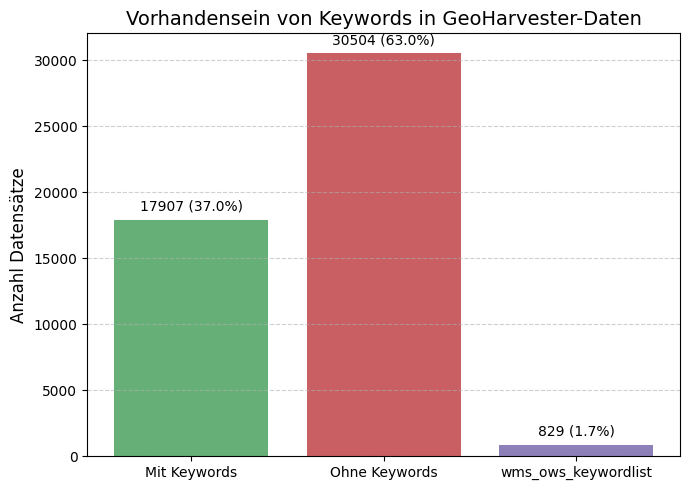


=== Beispiel: Mit Keywords ===


,provider,title,name,preview,tree,group,abstract,keywords,legend,contact,...,keywords_de,keywords_en,keywords_fr,keywords_it,keywords_nlp_de,keywords_nlp_en,keywords_nlp_fr,keywords_nlp_it,has_keywords,has_wms_ows
17522,KT_AR,Ortsplan Gde,ch.geoportal.basiskarten_bodenbedeckung_bildda...,https://map.geo.admin.ch/?bgLayer=ch.swisstopo...,Der Ortsplan ist eine einfach lesbare Karte. E...,,,https://www.geoportal.ch/services/wms/ktar,n.a.,n.a.,...,https://www.geoportal.ch/services/wms/ktar,,,,,,,,True,False
19860,KT_BS,Parzellenplan Label Strassen,AVBS_200_Labels_Strassen_02,https://map.geo.admin.ch/?bgLayer=ch.swisstopo...,,,,https://wms.geo.bs.ch/,n.a.,n.a.,...,https://wms.geo.bs.ch/,,,,,,,,True,False
10997,KT_TG,Fliesstiefenkarte Wasser hq30,GK_Fliesstiefenkarte_Wasser_HQ30,https://map.geo.admin.ch/?bgLayer=ch.swisstopo...,KT_TG/Fliesstiefenkarte Wasser hq30/GK_Fliesst...,GK_Fliesstiefenkarte_Wasser_HQ30,WMS/WFS Dienst des Kantons Thurgau,"WMS, WFS, Kanton Thurgau",https://ows.geo.tg.ch/geofy_access_proxy/ng_fl...,,...,"WMS, WFS, Kanton Thurgau",,,,"kantons thurgau, wms, wfs dienst","canton thurgau,wms,wfs service","Canton de Thurgovie,wms,service wfs","Canton Turgovia,wms,servizio wfs",True,False
23712,KT_SZ,"ÖREB: Nutzungsplanung kommunal, Morschach, übe...",ch.sz.a094b.oereb.raumplanung.nutzungsplanung_...,https://map.geo.admin.ch/?bgLayer=ch.swisstopo...,"ÖREB: Nutzungsplanung kommunal, Morschach, übe...",,,https://map.geo.sz.ch/mapserv_proxy,n.a.,n.a.,...,https://map.geo.sz.ch/mapserv_proxy,,,,,,,,True,False
26496,KT_FR,Plan d ensemble 1:5000 2010,0,https://map.geo.admin.ch/?bgLayer=ch.swisstopo...,DESCRIPTION_PE_5000_2010,,,https://geo.fr.ch/ags/services/OpenData_Raster...,n.a.,n.a.,...,,,https://geo.fr.ch/ags/services/OpenData_Raster...,,,,,,True,False



=== Beispiel: Ohne Keywords ===


,provider,title,name,preview,tree,group,abstract,keywords,legend,contact,...,keywords_de,keywords_en,keywords_fr,keywords_it,keywords_nlp_de,keywords_nlp_en,keywords_nlp_fr,keywords_nlp_it,has_keywords,has_wms_ows
14091,KT_ZH,S5 Wald entlang Bahnen und Leitungen (371.21),ms:ogd-0371_giszhpub_wep10_bz_wald_entlang_bul_f,n.a.,KT_ZH/OGD ZH WFS/ms:ogd-0371_giszhpub_wep10_bz...,ms:ogd-0371_giszhpub_wep10_bz_wald_entlang_bul_f,S5 Wald entlang Bahnen und Leitungen wird im P...,,,gis@bd.zh.ch,...,,,,,leitungen,cables,câbles,cavi,False,False
8724,KT_TI,[TI-028b.1] Mendrisio-Genestrerio - PT-EAP,ti.028b_1.ch088m2z_pt_eap,https://map.geo.admin.ch/?bgLayer=ch.swisstopo...,KT_TI/Geoservizi dei dati relativi al territor...,ti.028b_1.ch088m2z,Atto pianificatorio: Mendrisio-Genestrerio - P...,,https://wms.geo.ti.ch/service?format=image%2Fp...,,...,In,In,Dans,In,"Grafikplan, konforme Planungsurkunde, 06, Plan...","graphic plan, compliant planning deed, 06, pla...","Plan graphique, acte de planification conforme...","piano grafico, atto pianificatorio conforme, 0...",False,False
6441,KT_JU,env_09_29_inventaire_cantonal_pistes_vtt,env_09_29_inventaire_cantonal_pistes_vtt,n.a.,KT_JU/env_09_29_inventaire_cantonal_pistes_vtt,env_09_29_inventaire_cantonal_pistes_vtt,,,,,...,,,,,,,,,False,False
796,KT_BS,Unfallschwerpunkt - unter Beobachtung,ms:US_UnterBeobachtung,n.a.,KT_BS/Kanton Basel-Stadt WFS/ms:US_UnterBeobac...,ms:US_UnterBeobachtung,,,,geo@bs.ch,...,In,In,Dans,In,hinein,into,dans,in,False,False
1516,KT_BE,Weitere,RELIGION_RELSTAET_VW_18612,https://map.geo.admin.ch/?bgLayer=ch.swisstopo...,"KT_BE/Bevölkerung, Gesellschaft und Kultur 01/...",,Im Kanton Bern sind verschiedene Religionsgeme...,,https://www.geoservice.apps.be.ch/geoservice3/...,,...,In,In,Dans,In,"kanton bern, beinhaltet informationen, digital...","Canton of Bern, contains information, digital ...","Canton of Bern, contient des informations, des...","Canton di Bern, contiene informazioni, spettac...",False,False



=== Beispiel: Mit 'wms_ows_keywordlist' ===


,provider,title,name,preview,tree,group,abstract,keywords,legend,contact,...,keywords_de,keywords_en,keywords_fr,keywords_it,keywords_nlp_de,keywords_nlp_en,keywords_nlp_fr,keywords_nlp_it,has_keywords,has_wms_ows
16595,Bund,LV95 Dreiecksvermaschung,ch.swisstopo.dreiecksvermaschung,https://map.geo.admin.ch/?bgLayer=ch.swisstopo...,Bund/WMS BGDI/ch.swisstopo.dreiecksvermaschung,,Die Dreiecksvermaschung auf Stufe Landesvermes...,ch.swisstopo.dreiecksvermaschung.wms_ows_keywo...,https://wms.geo.admin.ch/?version=1.3.0&servic...,,...,ch.swisstopo.dreiecksvermaschung.wms_ows_keywo...,,,,"kategorie 1, dreiecksvermaschung, einzelnen dr...","category 1,triangular meshing,individual trian...","catégorie 1,maillage triangulaire,triangles in...","categoria 1,maglia triangolare,singoli triango...",True,True
16948,Bund,Äschen: Kernzonen,ch.bafu.fischerei-aeschen_kernzonen,https://map.geo.admin.ch/?bgLayer=ch.swisstopo...,Bund/WMS BGDI/ch.bafu.fischerei-aeschen_kernzonen,,Der Datensatz zu den Äschenpopulationen von na...,ch.bafu.fischerei-aeschen_kernzonen.wms_ows_ke...,https://wms.geo.admin.ch/?version=1.3.0&servic...,,...,ch.bafu.fischerei-aeschen_kernzonen.wms_ows_ke...,,,,"laichplätze, schweiz, verbreitungsatlas, larve...","spawning grounds,Switzerland,distribution atla...","frayères,Suisse,atlas de distribution,habitat ...","zone di deposizione delle uova,Svizzera,atlant...",True,True
16986,Bund,Übersichtskarte Hydrogeologie,ch.bafu.hydrogeologie-uebersichtskarte,https://map.geo.admin.ch/?bgLayer=ch.swisstopo...,Bund/WMS BGDI/ch.bafu.hydrogeologie-uebersicht...,ch.bafu.hydrogeologie-uebersichtskarte,Grundwasser kommt in allen Gesteinen des Unter...,ch.bafu.hydrogeologie-uebersichtskarte.wms_ows...,https://wms.geo.admin.ch/?version=1.3.0&servic...,,...,ch.bafu.hydrogeologie-uebersichtskarte.wms_ows...,,,,"verschiedenen grundwasserleitertypen, jura ver...","different aquifer types,jura spread,undergroun...","différents types d aquifères,la loi s est prop...","diversi tipi di falde acquifere,legge diffusa,...",True,True
16733,Bund,Grundwasservulnerabilität 500,ch.swisstopo.geologie-hydrogeologische_karte-g...,https://map.geo.admin.ch/?bgLayer=ch.swisstopo...,Bund/WMS BGDI/ch.swisstopo.geologie-hydrogeolo...,,Das Bundesamt für Umwelt BAFU ist die zuständi...,ch.swisstopo.geologie-hydrogeologische_karte-g...,,,...,ch.swisstopo.geologie-hydrogeologische_karte-g...,,,,"zuständige fachstelle, schweiz, hydrogeologisc...","responsible department,Switzerland,hydrogeolog...","Departement responsable,Suisse,carte hydrogéol...","dipartimento responsabile,Svizzera,carta idrog...",True,True
10863,Bund,Eisen - Konzentrationen im Boden,ch.bafu.geochemischer-bodenatlas_schweiz_eisen,https://map.geo.admin.ch/?bgLayer=ch.swisstopo...,Bund/WMS BGDI/ch.bafu.geochemischer-bodenatlas...,,Interpolierte Element-Konzentrationen (mg/kg F...,ch.bafu.geochemischer-bodenatlas_schweiz_eisen...,https://wms.geo.admin.ch/de/?version=1.3.0&ser...,,...,ch.bafu.geochemischer-bodenatlas schweiz eisen...,Ch.bafu.Geochemischer-Bodenatlas Switzerland i...,Ch.bafu.geochemischer-bodenatlas Suisse Iron.w...,Ch.bafu.geochemischer-bodenatlas Svizzera iron...,"schweiz, agroscope, kretzschmar, königswasser ...","Switzerland, Agroscope, Kretzschmar, royal wat...","Suisse, agroscope, Kretzschmar, eau royale, co...","Svizzera, Agroscopio, Kretzschmar, acqua reale...",True,True


In [ ]:
# --- Analyse ---
geoheravester_data['has_keywords'] = geoheravester_data['keywords'].notna() & (
    geoheravester_data['keywords'].astype(str).str.strip() != ""
)

geoheravester_data['has_wms_ows'] = geoheravester_data['keywords'].astype(str).str.contains(
    "wms_ows_keywordlist", case=False, na=False
)

# --- Zählen ---
count_with_keywords = geoheravester_data['has_keywords'].sum()
count_without_keywords = len(geoheravester_data) - count_with_keywords
count_with_wms_ows = geoheravester_data['has_wms_ows'].sum()
total = len(geoheravester_data)

# --- Prozentwerte ---
share_with = count_with_keywords / total * 100
share_without = count_without_keywords / total * 100
share_wms_ows = count_with_wms_ows / total * 100

# --- Ausgabe ---
print("=== Keyword Presence (GeoHarvester) ===")
print(f"Gesamt: {total}")
print(f"Mit Keywords: {count_with_keywords} ({share_with:.1f}%)")
print(f"Mit 'wms_ows_keywordlist': {count_with_wms_ows} ({share_wms_ows:.1f}%)")
print(f"Ohne Keywords: {count_without_keywords} ({share_without:.1f}%)")

# --- Diagramm ---
categories = ["Mit Keywords", "Ohne Keywords", "wms_ows_keywordlist"]
counts = [count_with_keywords, count_without_keywords, count_with_wms_ows]
colors = ["#55A868", "#C44E52", "#8172B2"]

plt.figure(figsize=(7, 5))
bars = plt.bar(categories, counts, color=colors, alpha=0.9)

# Beschriftungen
for bar, count, share in zip(bars, counts, [share_with, share_without, share_wms_ows]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + total * 0.01,
        f"{count} ({share:.1f}%)",
        ha="center", va="bottom", fontsize=10
    )

plt.ylabel("Anzahl Datensätze", fontsize=12)
plt.title("Vorhandensein von Keywords in GeoHarvester-Daten", fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# --- Beispiel-Datensätze für jede Kategorie ---
print("\n=== Beispiel: Mit Keywords ===")
display(geoheravester_data[geoheravester_data['has_keywords']].sample(5, random_state=1))

print("\n=== Beispiel: Ohne Keywords ===")
display(geoheravester_data[~geoheravester_data['has_keywords']].sample(5, random_state=2))

print("\n=== Beispiel: Mit 'wms_ows_keywordlist' ===")
display(geoheravester_data[geoheravester_data['has_wms_ows']].sample(5, random_state=3))

In [ ]:
import zipfile
import xml.dom.minidom as minidom

zip_path = "C:\\Users\\ma1169948\\Downloads\\XML-FHNW(1).zip"


with zipfile.ZipFile(zip_path, "r") as z:
    with z.open("2020/01/06/DL_birchmeier14_20200106_082456_20200106_094055.xml") as f:
        raw_xml = f.read().decode("utf-8")

# Pretty-print
dom = minidom.parseString(raw_xml)
pretty_xml = dom.toprettyxml(indent="  ")

# Print only first 10 lines
lines = pretty_xml.splitlines()
for line in lines[:100]:
    print(line)


<?xml version="1.0" ?>
<?xml-stylesheet type="text/xsl" href="../../../ConnectionLog.xsl"?>
<Leica_Geosystems_Spider>
  <Xsl_Logo_Path>../../../</Xsl_Logo_Path>
  <NetworkName>Refnet</NetworkName>
  <ObservedRoverUserName/>
  <ObservedRoverUserCompany/>
  <SpiderVersion>Spider v7.4.1</SpiderVersion>
  <DiffOfUTCLocalTime>60</DiffOfUTCLocalTime>
  <PeriodOfConnection>01:15:59</PeriodOfConnection>
  <vwConnectionLog>
    <ID>6869668</ID>
    <JobID>439223</JobID>
    <Active>0</Active>
    <StartTimeConnection>2020-01-06 08:24:56</StartTimeConnection>
    <StartTimeSending>2020-01-06 08:24:57</StartTimeSending>
    <EndTimeConnection>2020-01-06 09:40:55</EndTimeConnection>
    <FirstSiteCode>LENZ</FirstSiteCode>
    <FirstRefStatID>0</FirstRefStatID>
    <FirstDistanceToStat>9930</FirstDistanceToStat>
    <LastSiteCode>LENZ</LastSiteCode>
    <LastRefStatID>0</LastRefStatID>
    <LastDistanceToStat>9947</LastDistanceToStat>
    <JobGUID>355640c6-58e4-4824-9c96-7b37144b31e0</JobGUID>
    